# Notebook 03 — Entraînement des modèles

| | |
|---|---|
| **Projet** | Application Intelligente de Scoring Client |
| **Entreprise** | Orus Services — filiale Salafin, Bank of Africa |
| **Auteure** | Fatima Zahra Ait Lamine |
| **Encadrante** | Mme. Kaoutar Loutfi |
| **Année** | PFE 2025 |

---

## Objectif de ce notebook

On entraîne ici **6 stratégies de modélisation** sur le train set preprocessé (notebook 02).  
Chaque stratégie est évaluée rapidement sur le **validation set** pour avoir une première idée des performances.  
La comparaison approfondie et le choix final se font dans le **notebook 04**.

> **Règle absolue :** Le test set n'est **jamais touché** dans ce notebook. Il est réservé à l'évaluation finale unique dans le notebook 04.

### Les 6 stratégies

| Stratégie | Description | Complexité |
|---|---|---|
| A — Multiclasse direct | Un seul modèle entraîné directement sur 3 classes | Baseline |
| B — Cascade | 2 modèles en série : ÉLEVÉ vs reste, puis FAIBLE vs MOYEN | Moyenne |
| C — Stacking | 3 modèles de base + méta-modèle qui apprend à les combiner | Élevée |
| D — Soft Voting | 3 modèles en parallèle, moyenne des probabilités | Moyenne |
| E — One-vs-Rest | 3 classifieurs binaires indépendants | Moyenne |
| F — XGBoost + Threshold Tuning | Un XGBoost avec seuil de décision ajusté pour ÉLEVÉ | Moyenne |

### Pourquoi tester plusieurs stratégies ?

En scoring bancaire, la **classe ÉLEVÉ est rare mais critique**. Un seul modèle multiclasse peut la traiter comme une classe parmi d'autres et la sous-performer. Les stratégies B, E et F sont conçues pour lui donner plus de poids. On compare objectivement pour choisir la meilleure.


---
## 1. Imports et configuration


In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pickle
import os
import warnings
import time

warnings.filterwarnings('ignore')

# Modèles
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.multiclass import OneVsRestClassifier
from xgboost import XGBClassifier

# Évaluation
from sklearn.metrics import (
    roc_auc_score, average_precision_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, recall_score
)
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Style graphique unifié
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})

COLORS = {
    'FAIBLE': '#27ae60',
    'MOYEN':  '#e67e22',
    'ELEVE':  '#e74c3c',
    'default':'#3498db',
}

FIGURES_PATH = 'figures/'
MODELS_PATH  = '../models/'
os.makedirs(FIGURES_PATH, exist_ok=True)
os.makedirs(MODELS_PATH, exist_ok=True)

print("✓ Imports OK")

✓ Imports OK


---
## 2. Chargement des données preprocessées

On charge les CSV générés par le notebook 02. Ces données sont déjà :
- Nettoyées (age=0 supprimé, sentinelles 98 imputées)
- Imputées (médianes calculées sur train)
- Cappées (outliers au p99 calculé sur train)
- Enrichies (features métier ajoutées)
- Scalées (StandardScaler fitté sur train)
- Rééquilibrées (SMOTE appliqué sur train uniquement)


In [37]:
# Chargement
X_train = pd.read_csv('../data/processed/X_train.csv')
X_val   = pd.read_csv('../data/processed/X_val.csv')
X_test  = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_val   = pd.read_csv('../data/processed/y_val.csv').squeeze()
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()

# Chargement du label map
with open(f'{MODELS_PATH}label_map_reverse.pkl', 'rb') as f:
    label_map_r = pickle.load(f)

with open(f'{MODELS_PATH}feature_cols.pkl', 'rb') as f:
    feature_cols = pickle.load(f)

print("Données chargées :")
print(f"  X_train : {X_train.shape}  — y_train : {y_train.shape}")
print(f"  X_val   : {X_val.shape}  — y_val   : {y_val.shape}")
print(f"  X_test  : {X_test.shape}  — y_test  : {y_test.shape}")
print()
print(f"Features ({len(feature_cols)}) : {feature_cols}")
print()
print("Distribution y_train (après SMOTE) :")
for enc, nom in sorted(label_map_r.items()):
    n = (y_train == enc).sum()
    print(f"  {enc} — {nom:<6} : {n:>7,} ({n/len(y_train)*100:.1f}%)")
print()
print("Distribution y_val (non resamplé — réalité terrain) :")
for enc, nom in sorted(label_map_r.items()):
    n = (y_val == enc).sum()
    print(f"  {enc} — {nom:<6} : {n:>7,} ({n/len(y_val)*100:.1f}%)")

Données chargées :
  X_train : (119054, 14)  — y_train : (119054,)
  X_val   : (22500, 14)  — y_val   : (22500,)
  X_test  : (22500, 14)  — y_test  : (22500,)

Features (14) : ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents', 'charges_mensuelles', 'score_retards', 'historique_financier', 'nb_credits_total']

Distribution y_train (après SMOTE) :
  0 — FAIBLE :  53,174 (44.7%)
  1 — MOYEN  :  43,920 (36.9%)
  2 — ELEVE  :  21,960 (18.4%)

Distribution y_val (non resamplé — réalité terrain) :
  0 — FAIBLE :  11,395 (50.6%)
  1 — MOYEN  :   9,411 (41.8%)
  2 — ELEVE  :   1,694 (7.5%)


---
## 3. Fonction d'évaluation commune

Pour comparer équitablement les 6 stratégies, on utilise une fonction unique qui calcule les mêmes métriques pour toutes.

### Métriques retenues

| Métrique | Calcul | Pourquoi |
|---|---|---|
| **ROC-AUC macro** | Moyenne du ROC-AUC par classe | Métrique principale — mesure la discrimination globale, robuste au déséquilibre. Objectif : > 0.75 (cahier des charges). |
| **PR-AUC ÉLEVÉ** | Aire sous la courbe Précision/Recall pour la classe ÉLEVÉ | Plus sévère que ROC-AUC sur classes déséquilibrées — ne se laisse pas diluer par les vrais négatifs majoritaires. |
| **Recall ÉLEVÉ** | TP_élevé / (TP_élevé + FN_élevé) | Priorité métier — un faux négatif (ÉLEVÉ classé FAIBLE) est le pire cas en scoring de risque. |
| **F1 ÉLEVÉ** | 2 × (précision × recall) / (précision + recall) | Informatif — équilibre précision/recall. Déjà dans le classification_report. |

> **Pourquoi PR-AUC plutôt que ROC-AUC seul ?**  
> ROC-AUC utilise les vrais négatifs au dénominateur. Avec 93% de non-ÉLEVÉ, il y a énormément de vrais négatifs qui "diluent" les faux positifs — le ROC-AUC peut rester élevé même si le modèle est médiocre sur ÉLEVÉ.  
> PR-AUC n'utilise pas les vrais négatifs. Elle pénalise immédiatement les faux positifs, révélant la vraie difficulté de détecter la classe minoritaire.

> **Baseline PR-AUC :** un modèle aléatoire obtient un PR-AUC égal à la proportion de la classe positive (~7% ici). Un PR-AUC de 0.40 sur ÉLEVÉ est donc excellent (×5.7 au-dessus de la baseline), même s'il paraît faible en valeur absolue.

> **Score et classe sont indépendants :** les deux sont calculés simultanément à partir de `predict_proba()`. Le score = P(ÉLEVÉ) × 100. La classe = argmax des probabilités (ou seuil custom dans la stratégie F). Ni l'un n'affecte l'autre.

In [38]:
def evaluer(nom, y_true, y_pred, y_proba, duree=None):
    """
    Calcule et affiche les métriques d'évaluation pour une stratégie.
    Retourne un dict de résultats pour le tableau comparatif.

    Métriques :
    - ROC-AUC macro  : performance globale, robuste au déséquilibre
    - PR-AUC ÉLEVÉ   : performance réelle sur la classe critique (non diluée par les TN)
    - Recall ÉLEVÉ   : priorité métier — ne pas rater les clients à risque
    - F1 par classe  : dans le classification_report ci-dessous
    """
    # ROC-AUC macro
    auc = roc_auc_score(y_true, y_proba, multi_class='ovr', average='macro')

    # PR-AUC sur la classe ÉLEVÉ (index 2) — binariser : ÉLEVÉ vs reste
    y_true_bin   = (y_true == 2).astype(int)
    pr_auc_eleve = average_precision_score(y_true_bin, y_proba[:, 2])

    # Recall par classe
    recalls  = recall_score(y_true, y_pred, average=None, labels=[0, 1, 2])
    r_faible = recalls[0]
    r_moyen  = recalls[1]
    r_eleve  = recalls[2]

    print(f"{'─'*60}")
    print(f"  {nom}")
    print(f"{'─'*60}")
    print(f"  ROC-AUC macro   : {auc:.4f}  {'✓ > 0.75' if auc > 0.75 else '✗ < 0.75'}")
    print(f"  PR-AUC ÉLEVÉ    : {pr_auc_eleve:.4f}  (baseline aléatoire ≈ 0.07)")
    print(f"  Recall ÉLEVÉ    : {r_eleve:.4f}  ← priorité métier")
    print(f"  Recall MOYEN    : {r_moyen:.4f}")
    print(f"  Recall FAIBLE   : {r_faible:.4f}")
    if duree:
        print(f"  Temps train     : {duree:.1f}s")
    print()
    print(classification_report(
        y_true, y_pred,
        target_names=['FAIBLE', 'MOYEN', 'ÉLEVÉ'],
        digits=3
    ))

    return {
        'strategie'    : nom,
        'roc_auc'      : round(auc, 4),
        'pr_auc_eleve' : round(pr_auc_eleve, 4),
        'recall_eleve' : round(r_eleve, 4),
        'recall_moyen' : round(r_moyen, 4),
        'recall_faible': round(r_faible, 4),
        'duree_s'      : round(duree, 1) if duree else None,
    }

# Tableau de résultats — rempli au fur et à mesure
resultats = []
print("✓ Fonction d'évaluation prête")

✓ Fonction d'évaluation prête


---
## 4. Stratégie A — Multiclasse direct (Baseline)

### Principe

C'est la stratégie la plus simple : un seul modèle entraîné directement sur les 3 classes.  
On teste trois algorithmes classiques du scoring bancaire et on garde le meilleur des trois comme baseline.

**Pourquoi trois algorithmes ?**

| Algorithme | Rôle dans le scoring bancaire |
|---|---|
| **Logistic Regression** | Référence historique du scoring — interprétable, rapide, performant sur données linéairement séparables |
| **Random Forest** | Robuste aux outliers résiduels, gère bien les interactions entre features |
| **XGBoost** | État de l'art sur les données tabulaires — généralement le plus performant |

Le meilleur des trois devient la **baseline** : toutes les autres stratégies doivent faire mieux pour justifier leur complexité supplémentaire.


In [39]:
# ── Logistic Regression ───────────────────────────────────────────────────
t0 = time.time()
lr_A = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    C=1.0,
    random_state=42,
    n_jobs=-1,
)
lr_A.fit(X_train, y_train)
duree_lr = time.time() - t0

y_pred_lr  = lr_A.predict(X_val)
y_proba_lr = lr_A.predict_proba(X_val)
res_lr = evaluer("A1 — Logistic Regression", y_val, y_pred_lr, y_proba_lr, duree_lr)

────────────────────────────────────────────────────────────
  A1 — Logistic Regression
────────────────────────────────────────────────────────────
  ROC-AUC macro   : 0.9016  ✓ > 0.75
  PR-AUC ÉLEVÉ    : 0.5535  (baseline aléatoire ≈ 0.07)
  Recall ÉLEVÉ    : 0.6553  ← priorité métier
  Recall MOYEN    : 0.6260
  Recall FAIBLE   : 0.9143
  Temps train     : 14.6s

              precision    recall  f1-score   support

      FAIBLE      0.826     0.914     0.868     11395
       MOYEN      0.905     0.626     0.740      9411
       ÉLEVÉ      0.329     0.655     0.438      1694

    accuracy                          0.774     22500
   macro avg      0.687     0.732     0.682     22500
weighted avg      0.822     0.774     0.782     22500



In [40]:
# ── Random Forest ─────────────────────────────────────────────────────────
t0 = time.time()
rf_A = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    max_depth=None,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1,
)
rf_A.fit(X_train, y_train)
duree_rf = time.time() - t0

y_pred_rf  = rf_A.predict(X_val)
y_proba_rf = rf_A.predict_proba(X_val)
res_rf = evaluer("A2 — Random Forest", y_val, y_pred_rf, y_proba_rf, duree_rf)

────────────────────────────────────────────────────────────
  A2 — Random Forest
────────────────────────────────────────────────────────────
  ROC-AUC macro   : 0.9521  ✓ > 0.75
  PR-AUC ÉLEVÉ    : 0.5715  (baseline aléatoire ≈ 0.07)
  Recall ÉLEVÉ    : 0.5124  ← priorité métier
  Recall MOYEN    : 0.9401
  Recall FAIBLE   : 0.9780
  Temps train     : 31.6s

              precision    recall  f1-score   support

      FAIBLE      0.975     0.978     0.976     11395
       MOYEN      0.943     0.940     0.941      9411
       ÉLEVÉ      0.516     0.512     0.514      1694

    accuracy                          0.927     22500
   macro avg      0.811     0.810     0.811     22500
weighted avg      0.927     0.927     0.927     22500



In [41]:
# ── XGBoost ───────────────────────────────────────────────────────────────
# scale_pos_weight n'est pas disponible en multiclasse — on utilise sample_weight
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

t0 = time.time()
xgb_A = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss',
    verbosity=0,
    n_jobs=-1,
)
xgb_A.fit(X_train, y_train, sample_weight=sample_weights)
duree_xgb = time.time() - t0

y_pred_xgb  = xgb_A.predict(X_val)
y_proba_xgb = xgb_A.predict_proba(X_val)
res_xgb = evaluer("A3 — XGBoost", y_val, y_pred_xgb, y_proba_xgb, duree_xgb)

resultats.extend([res_lr, res_rf, res_xgb])

────────────────────────────────────────────────────────────
  A3 — XGBoost
────────────────────────────────────────────────────────────
  ROC-AUC macro   : 0.9541  ✓ > 0.75
  PR-AUC ÉLEVÉ    : 0.5721  (baseline aléatoire ≈ 0.07)
  Recall ÉLEVÉ    : 0.5254  ← priorité métier
  Recall MOYEN    : 0.9361
  Recall FAIBLE   : 0.9730
  Temps train     : 16.2s

              precision    recall  f1-score   support

      FAIBLE      0.975     0.973     0.974     11395
       MOYEN      0.943     0.936     0.940      9411
       ÉLEVÉ      0.499     0.525     0.512      1694

    accuracy                          0.924     22500
   macro avg      0.806     0.811     0.808     22500
weighted avg      0.926     0.924     0.925     22500



### Lecture des résultats — Stratégie A

Le meilleur modèle de la stratégie A devient notre **baseline**.  
On s'attend à ce que XGBoost surpasse LR et RF sur ce type de données tabulaires bancaires, mais c'est à confirmer empiriquement.

> Si un modèle plus simple (LR) atteint des performances comparables à XGBoost, c'est une information précieuse — la simplicité est préférable en production bancaire pour l'explicabilité réglementaire.


---
## 5. Stratégie B — Cascade (2 modèles spécialisés)

### Principe

Au lieu d'un seul modèle qui gère les 3 classes simultanément, on décompose le problème en **2 questions binaires plus simples** :

```
Modèle 1 : Ce client est-il ÉLEVÉ ?
    → OUI  : score = ÉLEVÉ  (fin)
    → NON  : passer au modèle 2

Modèle 2 : Ce client est-il FAIBLE ou MOYEN ?
    → FAIBLE ou MOYEN selon la probabilité
```

### Pourquoi cette approche ?

La classe ÉLEVÉ est la plus critique métier. En lui dédiant un modèle binaire spécialisé, on peut l'optimiser indépendamment — notamment son seuil de décision — sans contrainte des autres classes.  
C'est une approche courante en détection de fraude et scoring de risque.


In [42]:
# ── Préparation des targets binaires ────────────────────────────────────
# Modèle 1 : ÉLEVÉ (2) vs reste (0 et 1)
y_train_B1 = (y_train == 2).astype(int)
y_val_B1   = (y_val   == 2).astype(int)

# Modèle 2 : sur les non-ÉLEVÉ uniquement — FAIBLE (0) vs MOYEN (1)
mask_train_B2 = (y_train != 2)
mask_val_B2   = (y_val   != 2)

X_train_B2 = X_train[mask_train_B2]
y_train_B2 = y_train[mask_train_B2]
X_val_B2   = X_val[mask_val_B2]
y_val_B2   = y_val[mask_val_B2]

print(f"Modèle 1 — train : {y_train_B1.sum():,} ÉLEVÉ / {(y_train_B1==0).sum():,} reste")
print(f"Modèle 2 — train : {(y_train_B2==0).sum():,} FAIBLE / {(y_train_B2==1).sum():,} MOYEN")

Modèle 1 — train : 21,960 ÉLEVÉ / 97,094 reste
Modèle 2 — train : 53,174 FAIBLE / 43,920 MOYEN


In [43]:
# ── Modèle 1 : Détecteur ÉLEVÉ ────────────────────────────────────────────
t0 = time.time()
xgb_B1 = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(y_train_B1 == 0).sum() / (y_train_B1 == 1).sum(),
    random_state=42,
    eval_metric='logloss',
    verbosity=0,
    n_jobs=-1,
)
xgb_B1.fit(X_train, y_train_B1)

# Évaluation intermédiaire du modèle 1
proba_B1_val = xgb_B1.predict_proba(X_val)[:, 1]
auc_B1 = roc_auc_score(y_val_B1, proba_B1_val)
print(f"Modèle 1 (ÉLEVÉ vs reste) — ROC-AUC : {auc_B1:.4f}")

# ── Modèle 2 : Discriminateur FAIBLE/MOYEN ────────────────────────────────
xgb_B2 = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    eval_metric='logloss',
    verbosity=0,
    n_jobs=-1,
)
xgb_B2.fit(X_train_B2, y_train_B2)
duree_B = time.time() - t0

print(f"Modèle 2 (FAIBLE vs MOYEN) — entraîné")
print(f"Temps total : {duree_B:.1f}s")

Modèle 1 (ÉLEVÉ vs reste) — ROC-AUC : 0.8819
Modèle 2 (FAIBLE vs MOYEN) — entraîné
Temps total : 11.0s


In [44]:
# ── Prédiction en cascade ─────────────────────────────────────────────────
def predict_cascade(X, model1, model2, seuil_eleve=0.5):
    """
    Applique les deux modèles en cascade.
    seuil_eleve : probabilité minimale pour classer ÉLEVÉ (tunable).
    """
    proba1 = model1.predict_proba(X)[:, 1]  # P(ÉLEVÉ)
    pred   = np.zeros(len(X), dtype=int)

    # Clients classés ÉLEVÉ
    mask_eleve = proba1 >= seuil_eleve
    pred[mask_eleve] = 2

    # Clients non-ÉLEVÉ → modèle 2
    mask_reste = ~mask_eleve
    if mask_reste.sum() > 0:
        X_reste = X[mask_reste] if hasattr(X, 'iloc') else X[mask_reste]
        pred[mask_reste] = model2.predict(X_reste)

    # Probabilités reconstituées [P(FAIBLE), P(MOYEN), P(ÉLEVÉ)]
    proba_final = np.zeros((len(X), 3))
    proba_final[:, 2] = proba1
    proba2 = model2.predict_proba(X)  # on calcule sur tout, on filtrera
    proba_final[:, 0] = (1 - proba1) * proba2[:, 0]  # P(FAIBLE) = P(non-ÉLEVÉ) × P(FAIBLE|non-ÉLEVÉ)
    proba_final[:, 1] = (1 - proba1) * proba2[:, 1]  # P(MOYEN)  = P(non-ÉLEVÉ) × P(MOYEN|non-ÉLEVÉ)

    return pred, proba_final

y_pred_B, y_proba_B = predict_cascade(X_val, xgb_B1, xgb_B2)
res_B = evaluer("B — Cascade (XGBoost×2)", y_val, y_pred_B, y_proba_B, duree_B)
resultats.append(res_B)

────────────────────────────────────────────────────────────
  B — Cascade (XGBoost×2)
────────────────────────────────────────────────────────────
  ROC-AUC macro   : 0.9546  ✓ > 0.75
  PR-AUC ÉLEVÉ    : 0.5782  (baseline aléatoire ≈ 0.07)
  Recall ÉLEVÉ    : 0.6482  ← priorité métier
  Recall MOYEN    : 0.8536
  Recall FAIBLE   : 0.9528
  Temps train     : 11.0s

              precision    recall  f1-score   support

      FAIBLE      0.978     0.953     0.965     11395
       MOYEN      0.957     0.854     0.902      9411
       ÉLEVÉ      0.365     0.648     0.467      1694

    accuracy                          0.888     22500
   macro avg      0.767     0.818     0.778     22500
weighted avg      0.923     0.888     0.902     22500



### Note sur le seuil de décision

La fonction `predict_cascade` expose un paramètre `seuil_eleve` (défaut = 0.5).  
En abaissant ce seuil (ex : 0.3), on classe plus de clients comme ÉLEVÉ → recall ÉLEVÉ augmente mais précision baisse.  
Ce tuning sera fait dans la **stratégie F** de façon systématique.


---
## 6. Stratégie C — Stacking (méta-learner)

### Principe

Le stacking combine plusieurs modèles de base via un **méta-modèle** qui apprend à corriger leurs erreurs respectives :

```
LR  ──┐
RF  ──┼── [prédictions] ──► Méta-modèle (LR) ──► prédiction finale
XGB ──┘
```

### Pourquoi StratifiedKFold est obligatoire ?

Sans cross-validation, le méta-modèle s'entraîne sur les prédictions que les modèles de base ont faites **sur leurs propres données d'entraînement** — ce qui est du data leakage. Avec `StratifiedKFold(n_splits=5)`, chaque fold permet aux modèles de base de prédire sur des données qu'ils n'ont pas vues, donnant des prédictions honnêtes au méta-modèle.


In [45]:
t0 = time.time()

# Modèles de base
estimators_C = [
    ('lr',  LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)),
    ('rf',  RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                   min_samples_leaf=5, random_state=42, n_jobs=-1)),
    ('xgb', XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=5,
                           eval_metric='mlogloss', verbosity=0, random_state=42, n_jobs=-1)),
]

# Méta-modèle
stacking_C = StackingClassifier(
    estimators=estimators_C,
    final_estimator=LogisticRegression(max_iter=1000, C=1.0, random_state=42),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    stack_method='predict_proba',  # on passe les probas au méta-modèle, pas les classes
    n_jobs=-1,
    passthrough=False,             # le méta-modèle voit uniquement les probas des modèles de base
)

stacking_C.fit(X_train, y_train)
duree_C = time.time() - t0

y_pred_C  = stacking_C.predict(X_val)
y_proba_C = stacking_C.predict_proba(X_val)
res_C = evaluer("C — Stacking (LR+RF+XGB → LR)", y_val, y_pred_C, y_proba_C, duree_C)
resultats.append(res_C)

────────────────────────────────────────────────────────────
  C — Stacking (LR+RF+XGB → LR)
────────────────────────────────────────────────────────────
  ROC-AUC macro   : 0.9412  ✓ > 0.75
  PR-AUC ÉLEVÉ    : 0.5433  (baseline aléatoire ≈ 0.07)
  Recall ÉLEVÉ    : 0.4315  ← priorité métier
  Recall MOYEN    : 0.9599
  Recall FAIBLE   : 0.9820
  Temps train     : 131.6s

              precision    recall  f1-score   support

      FAIBLE      0.972     0.982     0.977     11395
       MOYEN      0.934     0.960     0.947      9411
       ÉLEVÉ      0.557     0.432     0.486      1694

    accuracy                          0.931     22500
   macro avg      0.821     0.791     0.803     22500
weighted avg      0.925     0.931     0.927     22500



### Note sur le temps d'entraînement

Le stacking avec 5 folds entraîne chaque modèle de base **5 fois** + 1 fois pour le fit final. C'est la stratégie la plus lente. Si le gain de performance par rapport à XGBoost seul est marginal, ce n'est pas justifié en production.


---
## 7. Stratégie D — Soft Voting (ensemble parallèle)

### Principe

Trois modèles prédisent indépendamment, et la **moyenne de leurs probabilités** détermine la classe finale :

```
LR  ──► [0.6, 0.3, 0.1] ──┐
RF  ──► [0.5, 0.3, 0.2] ──┼── moyenne ──► [0.53, 0.30, 0.17] ──► FAIBLE
XGB ──► [0.5, 0.3, 0.2] ──┘
```

### Pourquoi "soft" et pas "hard" voting ?

Le hard voting prend la majorité des classes prédites — il perd l'information de confiance.  
Le soft voting moyenne les **probabilités** — un modèle très confiant (P=0.9) a plus d'influence qu'un modèle hésitant (P=0.55). C'est généralement plus performant.


In [46]:
t0 = time.time()

estimators_D = [
    ('lr',  LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)),
    ('rf',  RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                   min_samples_leaf=5, random_state=42, n_jobs=-1)),
    ('xgb', XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=6,
                           eval_metric='mlogloss', verbosity=0, random_state=42, n_jobs=-1)),
]

voting_D = VotingClassifier(
    estimators=estimators_D,
    voting='soft',
    n_jobs=-1,
)
voting_D.fit(X_train, y_train)
duree_D = time.time() - t0

y_pred_D  = voting_D.predict(X_val)
y_proba_D = voting_D.predict_proba(X_val)
res_D = evaluer("D — Soft Voting (LR+RF+XGB)", y_val, y_pred_D, y_proba_D, duree_D)
resultats.append(res_D)

────────────────────────────────────────────────────────────
  D — Soft Voting (LR+RF+XGB)
────────────────────────────────────────────────────────────
  ROC-AUC macro   : 0.9534  ✓ > 0.75
  PR-AUC ÉLEVÉ    : 0.5799  (baseline aléatoire ≈ 0.07)
  Recall ÉLEVÉ    : 0.5047  ← priorité métier
  Recall MOYEN    : 0.9418
  Recall FAIBLE   : 0.9817
  Temps train     : 46.3s

              precision    recall  f1-score   support

      FAIBLE      0.972     0.982     0.977     11395
       MOYEN      0.944     0.942     0.943      9411
       ÉLEVÉ      0.534     0.505     0.519      1694

    accuracy                          0.929     22500
   macro avg      0.817     0.809     0.813     22500
weighted avg      0.927     0.929     0.928     22500



---
## 8. Stratégie E — One-vs-Rest (OvR)

### Principe

On entraîne **3 classifieurs binaires indépendants** :
- Classifieur 1 : FAIBLE vs (MOYEN + ÉLEVÉ)
- Classifieur 2 : MOYEN  vs (FAIBLE + ÉLEVÉ)
- Classifieur 3 : ÉLEVÉ  vs (FAIBLE + MOYEN)

La classe avec la probabilité la plus haute gagne.

### Avantage

Chaque classifieur peut être **optimisé indépendamment** — notamment son seuil de décision. On peut rendre le classifieur ÉLEVÉ plus sensible sans affecter les autres.  
C'est la différence fondamentale avec le multiclasse direct (stratégie A) où un seul modèle gère tout.


In [47]:
t0 = time.time()

# XGBoost en mode OvR
ovr_E = OneVsRestClassifier(
    XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        eval_metric='logloss',
        verbosity=0,
        random_state=42,
        n_jobs=1,  # n_jobs=-1 sur OneVsRestClassifier, pas sur chaque estimateur
    ),
    n_jobs=-1,
)
ovr_E.fit(X_train, y_train)
duree_E = time.time() - t0

y_pred_E  = ovr_E.predict(X_val)
y_proba_E = ovr_E.predict_proba(X_val)
res_E = evaluer("E — One-vs-Rest (XGBoost)", y_val, y_pred_E, y_proba_E, duree_E)
resultats.append(res_E)

────────────────────────────────────────────────────────────
  E — One-vs-Rest (XGBoost)
────────────────────────────────────────────────────────────
  ROC-AUC macro   : 0.9548  ✓ > 0.75
  PR-AUC ÉLEVÉ    : 0.5782  (baseline aléatoire ≈ 0.07)
  Recall ÉLEVÉ    : 0.3743  ← priorité métier
  Recall MOYEN    : 0.9770
  Recall FAIBLE   : 0.9946
  Temps train     : 7.2s

              precision    recall  f1-score   support

      FAIBLE      0.968     0.995     0.981     11395
       MOYEN      0.929     0.977     0.953      9411
       ÉLEVÉ      0.705     0.374     0.489      1694

    accuracy                          0.941     22500
   macro avg      0.868     0.782     0.808     22500
weighted avg      0.932     0.941     0.932     22500



---
## 9. Stratégie F — XGBoost + Threshold Tuning

### Principe

Un seul XGBoost multiclasse, mais on **ajuste le seuil de décision** pour la classe ÉLEVÉ.  
Par défaut, `argmax(probas)` choisit la classe avec la probabilité la plus haute. Ici, on dit :

> "Si P(ÉLEVÉ) > seuil, classer ÉLEVÉ — même si P(MOYEN) est plus haute."

```python
# Exemple avec seuil = 0.25 :
probas = [0.40, 0.45, 0.15]  # argmax → MOYEN
# Avec threshold tuning :
# P(ÉLEVÉ) = 0.15 < 0.25 → on garde MOYEN

probas = [0.50, 0.30, 0.20]  # argmax → FAIBLE
# P(ÉLEVÉ) = 0.20 < 0.25 → on garde FAIBLE

probas = [0.40, 0.32, 0.28]  # argmax → FAIBLE
# P(ÉLEVÉ) = 0.28 > 0.25 → on classe ÉLEVÉ  ← différence !
```

### Pourquoi c'est important ?

Cela **sépare la décision du modèle** (probabilités) **de la règle métier** (seuil).  
Le modèle reste le même, mais on peut calibrer son comportement selon le contexte business sans le ré-entraîner.


In [48]:
# Le modèle XGBoost de la stratégie A est réutilisé
# (même modèle, seuil différent)

def predict_avec_seuil(model, X, seuil_eleve):
    """
    Prédiction avec seuil custom pour la classe ÉLEVÉ (index 2).
    Si P(ÉLEVÉ) >= seuil → classe ÉLEVÉ, sinon argmax normal.
    """
    proba = model.predict_proba(X)
    pred  = np.argmax(proba, axis=1)             # prédiction par défaut
    mask  = proba[:, 2] >= seuil_eleve           # clients où P(ÉLEVÉ) >= seuil
    pred[mask] = 2                               # forcer ÉLEVÉ
    return pred, proba

# Recherche du meilleur seuil sur le validation set
seuils      = np.arange(0.10, 0.51, 0.05)
recalls_F   = []
aucs_F      = []

print(f"{'Seuil':>8} {'ROC-AUC':>10} {'Recall ÉLEVÉ':>14} {'Recall MOYEN':>14} {'Recall FAIBLE':>14}")
print("─" * 65)

for seuil in seuils:
    y_pred_s, y_proba_s = predict_avec_seuil(xgb_A, X_val, seuil)
    auc_s    = roc_auc_score(y_val, y_proba_s, multi_class='ovr', average='macro')
    recalls_s = recall_score(y_val, y_pred_s, average=None, labels=[0, 1, 2])
    recalls_F.append(recalls_s[2])
    aucs_F.append(auc_s)
    print(f"{seuil:>8.2f} {auc_s:>10.4f} {recalls_s[2]:>14.4f} {recalls_s[1]:>14.4f} {recalls_s[0]:>14.4f}")

   Seuil    ROC-AUC   Recall ÉLEVÉ   Recall MOYEN  Recall FAIBLE
─────────────────────────────────────────────────────────────────
    0.10     0.9541         0.9014         0.5012         0.7088
    0.15     0.9541         0.8512         0.6200         0.8141
    0.20     0.9541         0.7981         0.7042         0.8729
    0.25     0.9541         0.7462         0.7711         0.9080
    0.30     0.9541         0.6978         0.8212         0.9328
    0.35     0.9541         0.6482         0.8576         0.9471
    0.40     0.9541         0.6092         0.8889         0.9589
    0.45     0.9541         0.5691         0.9139         0.9672
    0.50     0.9541         0.5254         0.9361         0.9730


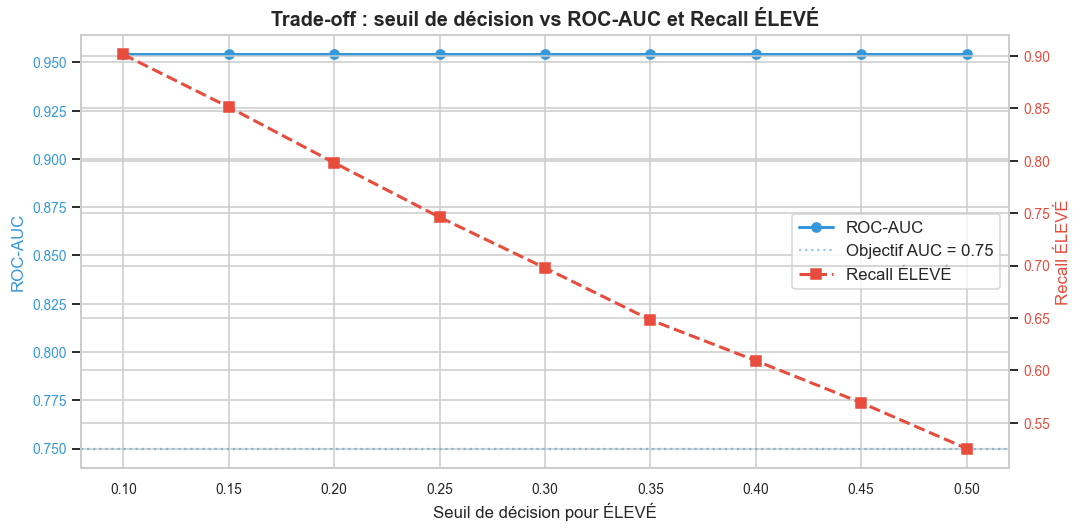

Figure sauvegardée : fig_11_threshold_tuning.png


In [49]:
# Visualisation du trade-off seuil vs recall ÉLEVÉ
fig, ax1 = plt.subplots(figsize=(10, 5))

color_auc    = '#3498db'
color_recall = COLORS['ELEVE']

ax1.plot(seuils, aucs_F, 'o-', color=color_auc, linewidth=2, markersize=6, label='ROC-AUC')
ax1.set_xlabel('Seuil de décision pour ÉLEVÉ')
ax1.set_ylabel('ROC-AUC', color=color_auc)
ax1.tick_params(axis='y', labelcolor=color_auc)
ax1.axhline(y=0.75, color=color_auc, linestyle=':', alpha=0.5, label='Objectif AUC = 0.75')

ax2 = ax1.twinx()
ax2.plot(seuils, recalls_F, 's--', color=color_recall, linewidth=2, markersize=6, label='Recall ÉLEVÉ')
ax2.set_ylabel('Recall ÉLEVÉ', color=color_recall)
ax2.tick_params(axis='y', labelcolor=color_recall)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')

ax1.set_title('Trade-off : seuil de décision vs ROC-AUC et Recall ÉLEVÉ')
ax1.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}fig_11_threshold_tuning.png', dpi=120, bbox_inches='tight')
plt.show()
print("Figure sauvegardée : fig_11_threshold_tuning.png")

In [50]:
# Choisir le meilleur seuil : maximiser recall ÉLEVÉ sous contrainte AUC > 0.75
meilleur_seuil = None
meilleur_recall_eleve = 0

for seuil, auc_s, recall_e in zip(seuils, aucs_F, recalls_F):
    if auc_s >= 0.75 and recall_e > meilleur_recall_eleve:
        meilleur_recall_eleve = recall_e
        meilleur_seuil = seuil

print(f"Meilleur seuil trouvé : {meilleur_seuil:.2f}")
print(f"  → Recall ÉLEVÉ      : {meilleur_recall_eleve:.4f}")
print()

t0 = time.time()
y_pred_F, y_proba_F = predict_avec_seuil(xgb_A, X_val, meilleur_seuil)
duree_F = time.time() - t0

res_F = evaluer(f"F — XGBoost + Threshold (seuil={meilleur_seuil:.2f})",
                y_val, y_pred_F, y_proba_F, duree_F)
resultats.append(res_F)

Meilleur seuil trouvé : 0.10
  → Recall ÉLEVÉ      : 0.9014

────────────────────────────────────────────────────────────
  F — XGBoost + Threshold (seuil=0.10)
────────────────────────────────────────────────────────────
  ROC-AUC macro   : 0.9541  ✓ > 0.75
  PR-AUC ÉLEVÉ    : 0.5721  (baseline aléatoire ≈ 0.07)
  Recall ÉLEVÉ    : 0.9014  ← priorité métier
  Recall MOYEN    : 0.5012
  Recall FAIBLE   : 0.7088
  Temps train     : 0.5s

              precision    recall  f1-score   support

      FAIBLE      0.988     0.709     0.825     11395
       MOYEN      0.984     0.501     0.664      9411
       ÉLEVÉ      0.160     0.901     0.272      1694

    accuracy                          0.636     22500
   macro avg      0.711     0.704     0.587     22500
weighted avg      0.924     0.636     0.716     22500



---
## 10. Tableau comparatif des 6 stratégies

On visualise maintenant les performances de toutes les stratégies côte à côte.  
La comparaison approfondie et le **choix final** se feront dans le notebook 04 avec des métriques supplémentaires.


In [51]:
# Tableau de résultats
df_res = pd.DataFrame(resultats).sort_values('roc_auc', ascending=False)
df_res['objectif_atteint'] = df_res['roc_auc'].apply(lambda x: '✓' if x >= 0.75 else '✗')

print("=" * 85)
print("TABLEAU COMPARATIF — TOUTES STRATÉGIES (trié par ROC-AUC décroissant)")
print("=" * 85)
print(df_res[['strategie', 'roc_auc', 'pr_auc_eleve', 'recall_eleve',
              'recall_moyen', 'recall_faible', 'objectif_atteint']].to_string(index=False))
print()
print(f"Objectif cahier des charges : ROC-AUC > 0.75")
print(f"Stratégies qui l'atteignent : {df_res['objectif_atteint'].value_counts().get('✓', 0)}/{len(df_res)}")
print()

# Meilleure stratégie selon chaque métrique
print("Meilleure stratégie par métrique :")
print(f"  ROC-AUC le plus élevé  : {df_res.loc[df_res['roc_auc'].idxmax(), 'strategie']}")
print(f"  PR-AUC ÉLEVÉ le plus élevé : {df_res.loc[df_res['pr_auc_eleve'].idxmax(), 'strategie']}")
print(f"  Recall ÉLEVÉ le plus élevé : {df_res.loc[df_res['recall_eleve'].idxmax(), 'strategie']}")

TABLEAU COMPARATIF — TOUTES STRATÉGIES (trié par ROC-AUC décroissant)
                           strategie  roc_auc  pr_auc_eleve  recall_eleve  recall_moyen  recall_faible objectif_atteint
           E — One-vs-Rest (XGBoost)   0.9548        0.5782        0.3743        0.9770         0.9946                ✓
             B — Cascade (XGBoost×2)   0.9546        0.5782        0.6482        0.8536         0.9528                ✓
F — XGBoost + Threshold (seuil=0.10)   0.9541        0.5721        0.9014        0.5012         0.7088                ✓
                        A3 — XGBoost   0.9541        0.5721        0.5254        0.9361         0.9730                ✓
         D — Soft Voting (LR+RF+XGB)   0.9534        0.5799        0.5047        0.9418         0.9817                ✓
                  A2 — Random Forest   0.9521        0.5715        0.5124        0.9401         0.9780                ✓
       C — Stacking (LR+RF+XGB → LR)   0.9412        0.5433        0.4315        0.9599   

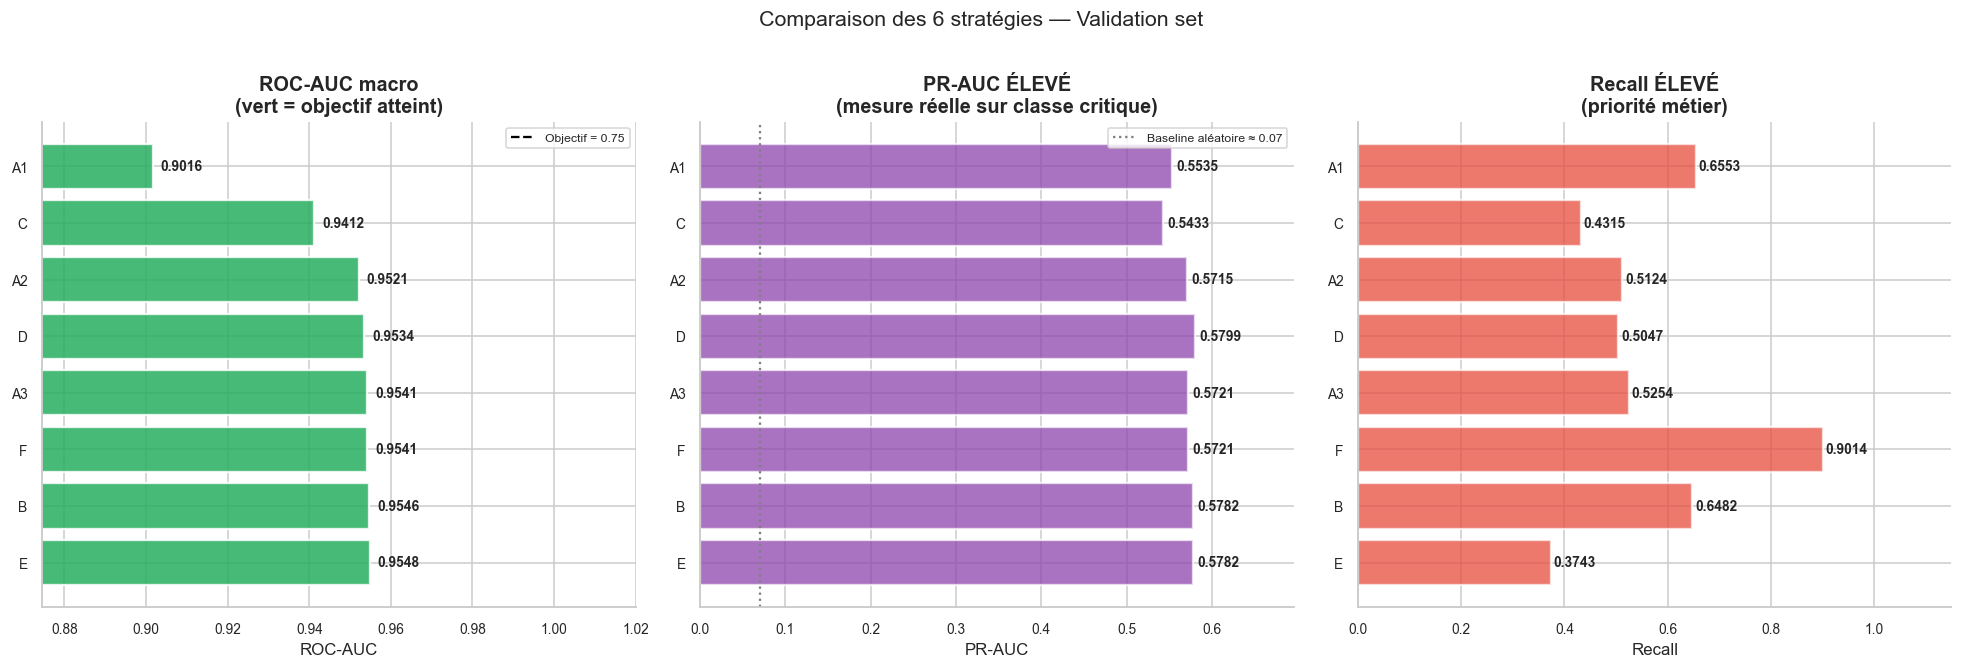

Figure sauvegardée : fig_12_strategies_comparison.png


In [52]:
# Visualisation comparative — 3 métriques
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

strategies = df_res['strategie'].str.split(' — ').str[0]

# ── ROC-AUC ───────────────────────────────────────────────────────────────
ax1 = axes[0]
bar_colors_auc = ['#27ae60' if v >= 0.75 else '#e74c3c' for v in df_res['roc_auc']]
bars1 = ax1.barh(strategies, df_res['roc_auc'],
                 color=bar_colors_auc, alpha=0.85, edgecolor='white', linewidth=1.5)
ax1.axvline(x=0.75, color='black', linestyle='--', linewidth=1.5, label='Objectif = 0.75')
for bar, val in zip(bars1, df_res['roc_auc']):
    ax1.text(val + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9, fontweight='bold')
ax1.set_title('ROC-AUC macro\n(vert = objectif atteint)')
ax1.set_xlabel('ROC-AUC')
ax1.legend(fontsize=8)
ax1.set_xlim(df_res['roc_auc'].min() * 0.97, 1.02)
ax1.spines[['top', 'right']].set_visible(False)

# ── PR-AUC ÉLEVÉ ──────────────────────────────────────────────────────────
ax2 = axes[1]
bars2 = ax2.barh(strategies, df_res['pr_auc_eleve'],
                  color='#8e44ad', alpha=0.75, edgecolor='white', linewidth=1.5)
ax2.axvline(x=0.07, color='gray', linestyle=':', linewidth=1.5, label='Baseline aléatoire ≈ 0.07')
for bar, val in zip(bars2, df_res['pr_auc_eleve']):
    ax2.text(val + 0.005, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9, fontweight='bold')
ax2.set_title('PR-AUC ÉLEVÉ\n(mesure réelle sur classe critique)')
ax2.set_xlabel('PR-AUC')
ax2.legend(fontsize=8)
ax2.set_xlim(0, df_res['pr_auc_eleve'].max() * 1.2)
ax2.spines[['top', 'right']].set_visible(False)

# ── Recall ÉLEVÉ ──────────────────────────────────────────────────────────
ax3 = axes[2]
bars3 = ax3.barh(strategies, df_res['recall_eleve'],
                  color=COLORS['ELEVE'], alpha=0.75, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars3, df_res['recall_eleve']):
    ax3.text(val + 0.005, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9, fontweight='bold')
ax3.set_title('Recall ÉLEVÉ\n(priorité métier)')
ax3.set_xlabel('Recall')
ax3.set_xlim(0, 1.15)
ax3.spines[['top', 'right']].set_visible(False)

plt.suptitle('Comparaison des 6 stratégies — Validation set', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}fig_12_strategies_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print("Figure sauvegardée : fig_12_strategies_comparison.png")

---
## 11. Sauvegarde des modèles entraînés

On sauvegarde tous les modèles entraînés pour les réutiliser dans le notebook 04 sans avoir à tout ré-entraîner.


In [53]:
modeles_a_sauvegarder = {
    'model_A_lr'  : lr_A,
    'model_A_rf'  : rf_A,
    'model_A_xgb' : xgb_A,
    'model_B1'    : xgb_B1,
    'model_B2'    : xgb_B2,
    'model_C'     : stacking_C,
    'model_D'     : voting_D,
    'model_E'     : ovr_E,
    # Stratégie F réutilise model_A_xgb avec seuil_eleve
    'seuil_F'     : meilleur_seuil,
}

for nom, objet in modeles_a_sauvegarder.items():
    path = f'{MODELS_PATH}{nom}.pkl'
    with open(path, 'wb') as f:
        pickle.dump(objet, f, protocol=4)
    print(f"✓ {nom:<20} → {path}")

# Sauvegarder aussi le tableau de résultats
df_res.to_csv(f'{MODELS_PATH}resultats_validation.csv', index=False)
print()
print(f"✓ Tableau de résultats → {MODELS_PATH}resultats_validation.csv")

✓ model_A_lr           → ../models/model_A_lr.pkl
✓ model_A_rf           → ../models/model_A_rf.pkl
✓ model_A_xgb          → ../models/model_A_xgb.pkl
✓ model_B1             → ../models/model_B1.pkl
✓ model_B2             → ../models/model_B2.pkl
✓ model_C              → ../models/model_C.pkl
✓ model_D              → ../models/model_D.pkl
✓ model_E              → ../models/model_E.pkl
✓ seuil_F              → ../models/seuil_F.pkl

✓ Tableau de résultats → ../models/resultats_validation.csv


---
## 12. Synthèse

### Ce qui a été fait dans ce notebook

| Étape | Détail |
|---|---|
| Chargement | 6 CSV preprocessés depuis `data/processed/` |
| Stratégie A | LR, RF, XGBoost en multiclasse direct — baseline |
| Stratégie B | Cascade XGBoost×2 — modèle spécialisé ÉLEVÉ |
| Stratégie C | Stacking LR+RF+XGB avec méta-modèle LR (StratifiedKFold×5) |
| Stratégie D | Soft Voting LR+RF+XGB — moyenne des probabilités |
| Stratégie E | One-vs-Rest XGBoost — 3 classifieurs binaires indépendants |
| Stratégie F | XGBoost + seuil de décision optimisé pour ÉLEVÉ |
| Sauvegarde | Tous les modèles + tableau de résultats dans `models/` |

### Métriques utilisées

| Métrique | Rôle |
|---|---|
| ROC-AUC macro | Performance globale — critère principal de sélection |
| PR-AUC ÉLEVÉ | Performance réelle sur la classe critique — plus sévère que ROC-AUC sur données déséquilibrées |
| Recall ÉLEVÉ | Priorité métier — minimiser les faux négatifs sur les clients à risque |
| F1 par classe | Informatif — visible dans le classification_report de chaque stratégie |

### Ce qui n'a PAS encore été fait

- ❌ Évaluation sur le **test set** — réservée au notebook 04
- ❌ Choix définitif de la meilleure stratégie — notebook 04
- ❌ Matrices de confusion détaillées — notebook 04
- ❌ SHAP values et narration — notebook 05

---

**Prochaine étape → Notebook 04 — Évaluation**  
Comparaison approfondie sur le validation set, choix de la meilleure stratégie, puis évaluation **une seule fois** sur le test set.